# Airflow Performance Analysis
This notebook explores the execution duration of the `citibike_ingestion` DAG over time, including a linear trend analysis to identify performance regressions or improvements.

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
from dotenv import load_dotenv
from scipy import stats

# Set aesthetics
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = [12, 6]

load_dotenv('secrets.env')
load_dotenv('settings.env', override=True)

def get_conn_str():
    user = os.getenv("DB_USER")
    password = os.getenv("DB_PASSWORD")
    host = os.getenv("DB_HOST")
    port = os.getenv("DB_PORT")
    name = os.getenv("DB_NAME")
    # Append the search_path to the connection string if needed
    return f"postgresql://{user}:{password}@{host}:{port}/{name}"

engine = create_engine(get_conn_str())

## 1. Data Retrieval
We query the `airflow.dag_run` table for successful runs of our ingestion pipeline.

In [6]:
query = """
SELECT 
    dag_id,
    run_id,
    start_date,
    end_date,
    EXTRACT(EPOCH FROM (end_date - start_date)) as duration_seconds
FROM airflow.dag_run 
WHERE state = 'success'
AND dag_id = 'citibike_ingestion'
ORDER BY start_date;
"""

from sqlalchemy import text
with engine.connect() as conn:
    result = conn.execute(text(query))
    df = pd.DataFrame(result.fetchall(), columns=result.keys())

assert df.shape[0] > 0
df['start_date'] = pd.to_datetime(df['start_date'])
df['start_date'] = df['start_date'].dt.tz_convert('America/New_York')
df['end_date'] = pd.to_datetime(df['end_date'])
df['end_date'] = df['end_date'].dt.tz_convert('America/New_York')

df.head()

,dag_id,run_id,start_date,end_date,duration_seconds
0,citibike_ingestion,scheduled__2026-04-08T20:35:00+00:00,2026-04-08 16:36:22.775164-04:00,2026-04-08 16:36:38.538203-04:00,15.763039
1,citibike_ingestion,scheduled__2026-04-08T20:36:00+00:00,2026-04-08 16:37:00.937861-04:00,2026-04-08 16:37:16.427036-04:00,15.489175
2,citibike_ingestion,scheduled__2026-04-08T20:37:00+00:00,2026-04-08 16:38:00.661315-04:00,2026-04-08 16:38:16.003755-04:00,15.342440
3,citibike_ingestion,scheduled__2026-04-08T20:38:00+00:00,2026-04-08 16:39:00.751089-04:00,2026-04-08 16:39:14.680568-04:00,13.929479
4,citibike_ingestion,scheduled__2026-04-08T20:39:00+00:00,2026-04-08 16:40:00.487969-04:00,2026-04-08 16:40:17.189123-04:00,16.701154


## 2. Performance Visualization
Plotting the run duration over time to visualize trends.

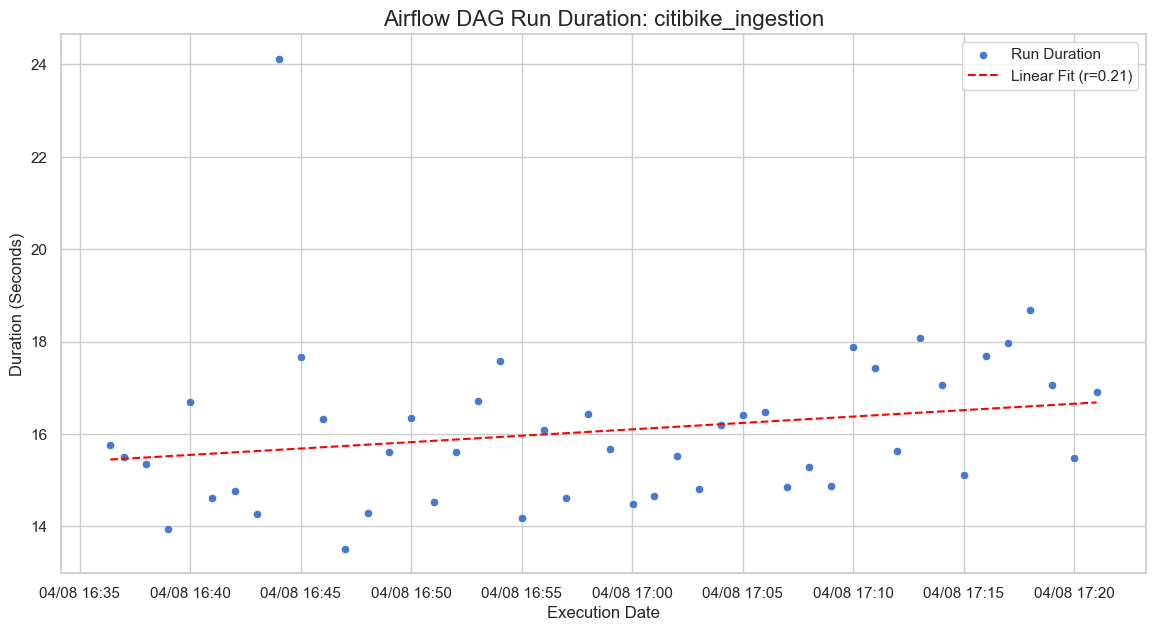

Average Duration: 16.06 seconds
Performance Trend: Degrading (1.6620 sec/hour)


In [7]:
import matplotlib.dates as mdates
import pytz

plt.figure(figsize=(14, 7))
sns.scatterplot(data=df, x='start_date', y='duration_seconds', label='Run Duration')

# Calculate Linear Fit
df['start_ts'] = (df['start_date'] - df['start_date'].iloc[0]).dt.total_seconds()
x = df['start_ts'].to_numpy(dtype=float)
y = df['duration_seconds'].to_numpy(dtype=float)

slope, intercept = np.polyfit(x, y, 1)

# Compute r value manually
y_hat = slope * x + intercept
ss_res = np.sum((y - y_hat) ** 2)
ss_tot = np.sum((y - y.mean()) ** 2)
r_value = np.sqrt(1 - ss_res / ss_tot)

# Generate values for the fit line
df['linear_fit'] = y_hat

# Plot Linear Fit
sns.lineplot(data=df, x='start_date', y='linear_fit', color='red', linestyle='--', label=f'Linear Fit (r={r_value:.2f})')

plt.title('Airflow DAG Run Duration: citibike_ingestion', fontsize=16)
plt.xlabel('Execution Date', fontsize=12)
plt.ylabel('Duration (Seconds)', fontsize=12)

# Format x‑axis
ax = plt.gca()
ax.xaxis.set_major_formatter(
    mdates.DateFormatter('%m/%d %H:%M', tz=pytz.timezone('America/New_York'))
)

plt.legend()
plt.show()

print(f"Average Duration: {df['duration_seconds'].mean():.2f} seconds")
print(f"Performance Trend: {'Improving' if slope < 0 else 'Degrading'} ({abs(slope*3600):.4f} sec/hour)")

## 3. Statistical Insight
A quick look at the distribution of run times.

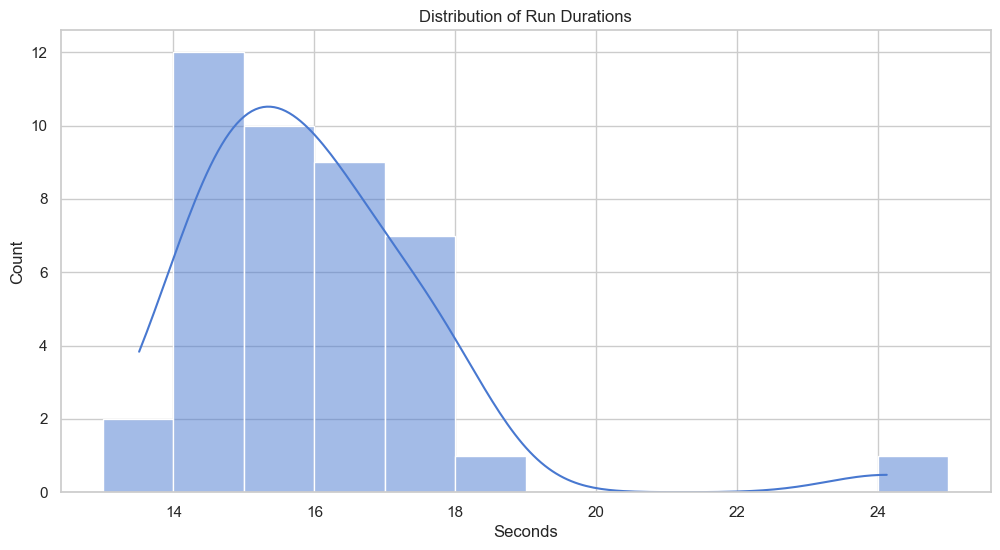

In [4]:
bins = range(int(min(y)), int(max(y))+2)
sns.histplot(df['duration_seconds'], kde=True, bins=bins)
plt.title('Distribution of Run Durations')
plt.xlabel('Seconds')
plt.show()